# Predicting Dementia Diagnosis Using Lifestyle and Health Factors

CS4403 Project Data Cleaning and Preprocessing
Taryn Cail - 3756155



In [91]:
#Imports used in this Project File
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, classification_report
import time
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, classification_report
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

import pandas as pd
import numpy as np

# Preprocessing and modeling
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Install required packages
!pip install scikit-learn xgboost lightgbm shap matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling and preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import shap

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('bin', 'passthrough', binary_cols)
    ]
)


# Data Dictionary

Data Dictionary provided by Rabie El Kharoua who created the dataset on Kaggle.
https://www.kaggle.com/datasets/rabieelkharoua/alzheimers-disease-dataset

This dataset contains extensive health information for 2,149 patients, each uniquely identified with IDs ranging from 4751 to 6900. The dataset includes demographic details, lifestyle factors, medical history, clinical measurements, cognitive and functional assessments, symptoms, and a diagnosis of Alzheimer's Disease. The data is ideal for researchers and data scientists looking to explore factors associated with Alzheimer's, develop predictive models, and conduct statistical analyses.

Table of Contents

Patient Information
- Patient ID
- Demographic Details
- Lifestyle Factors
- Medical History
- Clinical Measurements
- Cognitive and Functional Assessments
- Symptoms
- Diagnosis Information
- Confidential Information


Patient Information
- Patient ID
- PatientID: A unique identifier assigned to each patient (4751 to 6900).


Demographic Details
- Age: The age of the patients ranges from 60 to 90 years.
- Gender: Gender of the patients, where 0 represents Male and 1 represents Female.
- Ethnicity: The ethnicity of the patients, coded as follows:
  - 0: Caucasian
  - 1: African American
  - 2: Asian
  - 3: Other
- EducationLevel: The education level of the patients, coded as follows:
  - 0: None
  - 1: High School
  - 2: Bachelor's
  - 3: Higher


Lifestyle Factors
- BMI: Body Mass Index of the patients, ranging from 15 to 40.
- Smoking: Smoking status, where 0 indicates No and 1 indicates Yes.
- AlcoholConsumption: Weekly alcohol consumption in units, ranging from 0 to 20.
- PhysicalActivity: Weekly physical activity in hours, ranging from 0 to 10.
- DietQuality: Diet quality score, ranging from 0 to 10.
- SleepQuality: Sleep quality score, ranging from 4 to 10.


Medical History
- FamilyHistoryAlzheimers: Family history of Alzheimer's Disease, where 0 indicates No and 1 indicates Yes.
- CardiovascularDisease: Presence of cardiovascular disease, where 0 indicates No and 1 indicates Yes.
- Diabetes: Presence of diabetes, where 0 indicates No and 1 indicates Yes.
- Depression: Presence of depression, where 0 indicates No and 1 indicates Yes.
- HeadInjury: History of head injury, where 0 indicates No and 1 indicates Yes.
- Hypertension: Presence of hypertension, where 0 indicates No and 1 indicates Yes.


Clinical Measurements
- SystolicBP: Systolic blood pressure, ranging from 90 to 180 mmHg.
- DiastolicBP: Diastolic blood pressure, ranging from 60 to 120 mmHg.
- CholesterolTotal: Total cholesterol levels, ranging from 150 to 300 mg/dL.
- CholesterolLDL: Low-density lipoprotein cholesterol levels, ranging from 50 to 200 mg/dL.
- CholesterolHDL: High-density lipoprotein cholesterol levels, ranging from 20 to 100 mg/dL.
- CholesterolTriglycerides: Triglycerides levels, ranging from 50 to 400 mg/dL.


Cognitive and Functional Assessments
- MMSE: Mini-Mental State Examination score, ranging from 0 to 30. Lower scores indicate cognitive impairment.
- FunctionalAssessment: Functional assessment score, ranging from 0 to 10. Lower scores indicate greater impairment.
- MemoryComplaints: Presence of memory complaints, where 0 indicates No and 1 indicates Yes.
- BehavioralProblems: Presence of behavioral problems, where 0 indicates No and 1 indicates Yes.
- ADL: Activities of Daily Living score, ranging from 0 to 10. Lower scores indicate greater impairment.


Symptoms
- Confusion: Presence of confusion, where 0 indicates No and 1 indicates Yes.
- Disorientation: Presence of disorientation, where 0 indicates No and 1 indicates Yes.
- PersonalityChanges: Presence of personality changes, where 0 indicates No and 1 indicates Yes.
- DifficultyCompletingTasks: Presence of difficulty completing tasks, where 0 indicates No and 1 indicates Yes.
- Forgetfulness: Presence of forgetfulness, where 0 indicates No and 1 indicates Yes.


Diagnosis Information
- Diagnosis: Diagnosis status for Alzheimer's Disease, where 0 indicates No and 1 indicates Yes.


Confidential Information
- DoctorInCharge: This column contains confidential information about the doctor in charge, with "XXXConfid" as the value for all patients.


Conclusion
This dataset offers extensive insights into the factors associated with Alzheimer's Disease, including demographic, lifestyle, medical, cognitive, and functional variables. It is ideal for developing predictive models, conducting statistical analyses, and exploring the complex interplay of factors contributing to Alzheimer's Disease.

# Data Cleaning and Preprocessing

## Importing CSV File

In [92]:
url = "https://raw.githubusercontent.com/Taryn-Cail/Predicting-Dementia-Diagnosis-Using-Lifestyle-and-Health-Factors/refs/heads/main/alzheimers_disease_data.csv"
df = pd.read_csv(url)

df.head()


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


##Reviewing the Data

In [93]:
# print all the data frames to compare and contrast information
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

##Removing Columns

In [94]:
# Indicating which columns to be removed
columns_to_remove = [
    'PatientID',
    'DoctorInCharge',
    'SystolicBP',
    'DiastolicBP',
    'CholesterolLDL',
    'CholesterolHDL',
    'CholesterolTriglycerides'
]


I am choosing to remove these columns because:

- PatientID is irrelevant to the prediction and modelling
- DoctorInCharge is also irrelevant and does not contain specific data that is useful
- SystolicBP is the highest blood pressure reading and Diastolic blood pressure is the lowest reading of blood pressure. These are much more clinical terms that are outside of the scope of my personal knowledge and rely on one another to complete the whole picture.
- Cholesterol HDL and LDL are the lowest and highest readings of cholesterol which are also more clinical terms and have colinearity with Cholesterol Total so will be removed to limit the clincial scope of the project to something I can interpret.

In [95]:
#removing columns from list
df = df.drop(columns=columns_to_remove)


In [96]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   int64  
 1   Gender                     2149 non-null   int64  
 2   Ethnicity                  2149 non-null   int64  
 3   EducationLevel             2149 non-null   int64  
 4   BMI                        2149 non-null   float64
 5   Smoking                    2149 non-null   int64  
 6   AlcoholConsumption         2149 non-null   float64
 7   PhysicalActivity           2149 non-null   float64
 8   DietQuality                2149 non-null   float64
 9   SleepQuality               2149 non-null   float64
 10  FamilyHistoryAlzheimers    2149 non-null   int64  
 11  CardiovascularDisease      2149 non-null   int64  
 12  Diabetes                   2149 non-null   int64  
 13  Depression                 2149 non-null   int64

In [97]:
# Checking for missing values
df.isnull().sum()

,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0
SleepQuality,0


## Splitting Data into Type

In [98]:
binary_cols = [
    "Gender", "Smoking", "FamilyHistoryAlzheimers", "CardiovascularDisease",
    "Diabetes", "Depression", "HeadInjury", "Hypertension", "MemoryComplaints",
    "BehavioralProblems", "Confusion", "Disorientation", "PersonalityChanges",
    "DifficultyCompletingTasks", "Forgetfulness"
]

# Ensure categorical features are object type
categorical_cols = ["Ethnicity", "EducationLevel"]
for col in categorical_cols:
    X[col] = X[col].astype(str)

# Numerical features (all remaining)
numerical_cols = [c for c in X.columns if c not in binary_cols + categorical_cols]



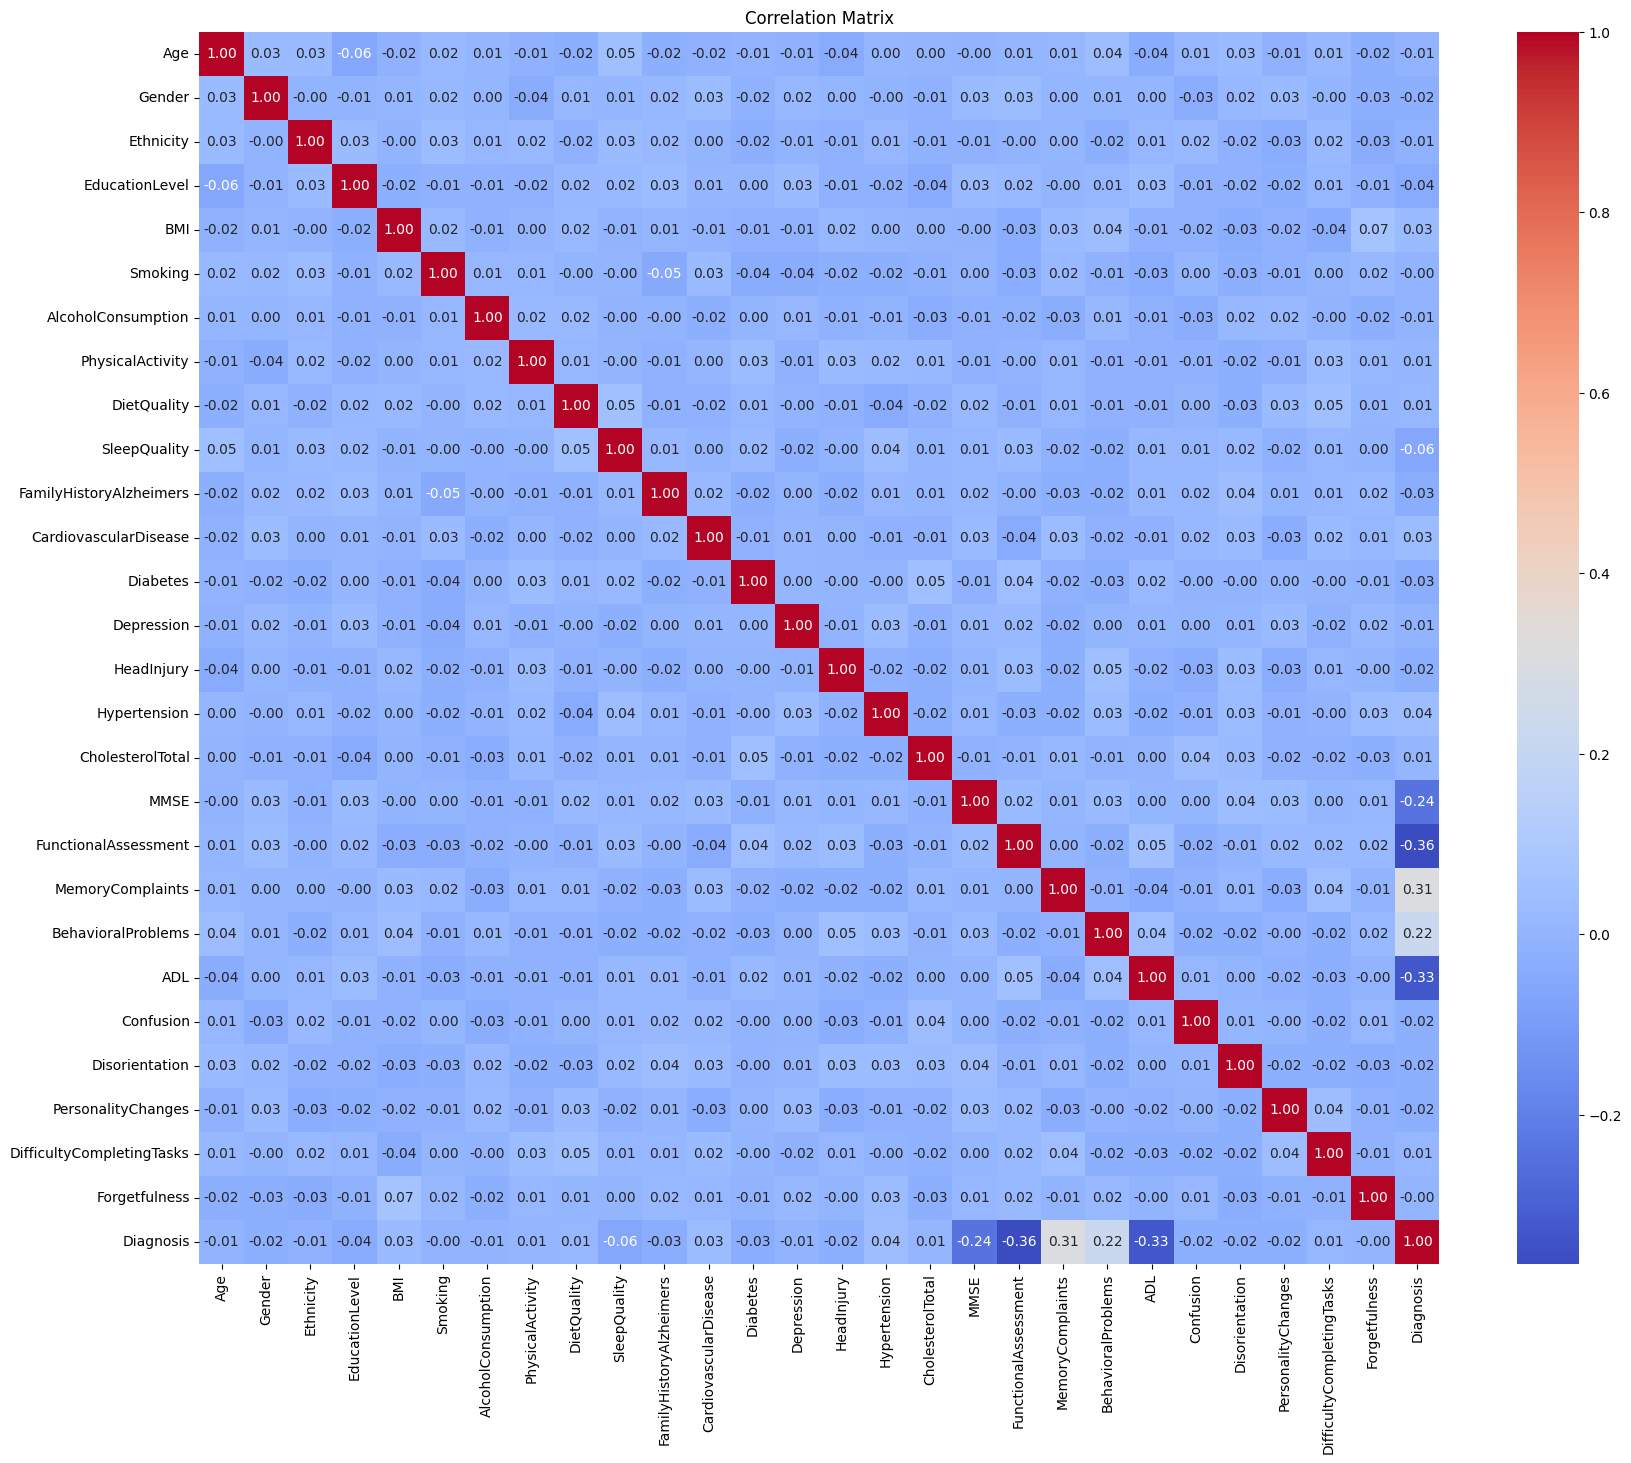

In [113]:
# Creating a correlation matrix
corr_matrix = df.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

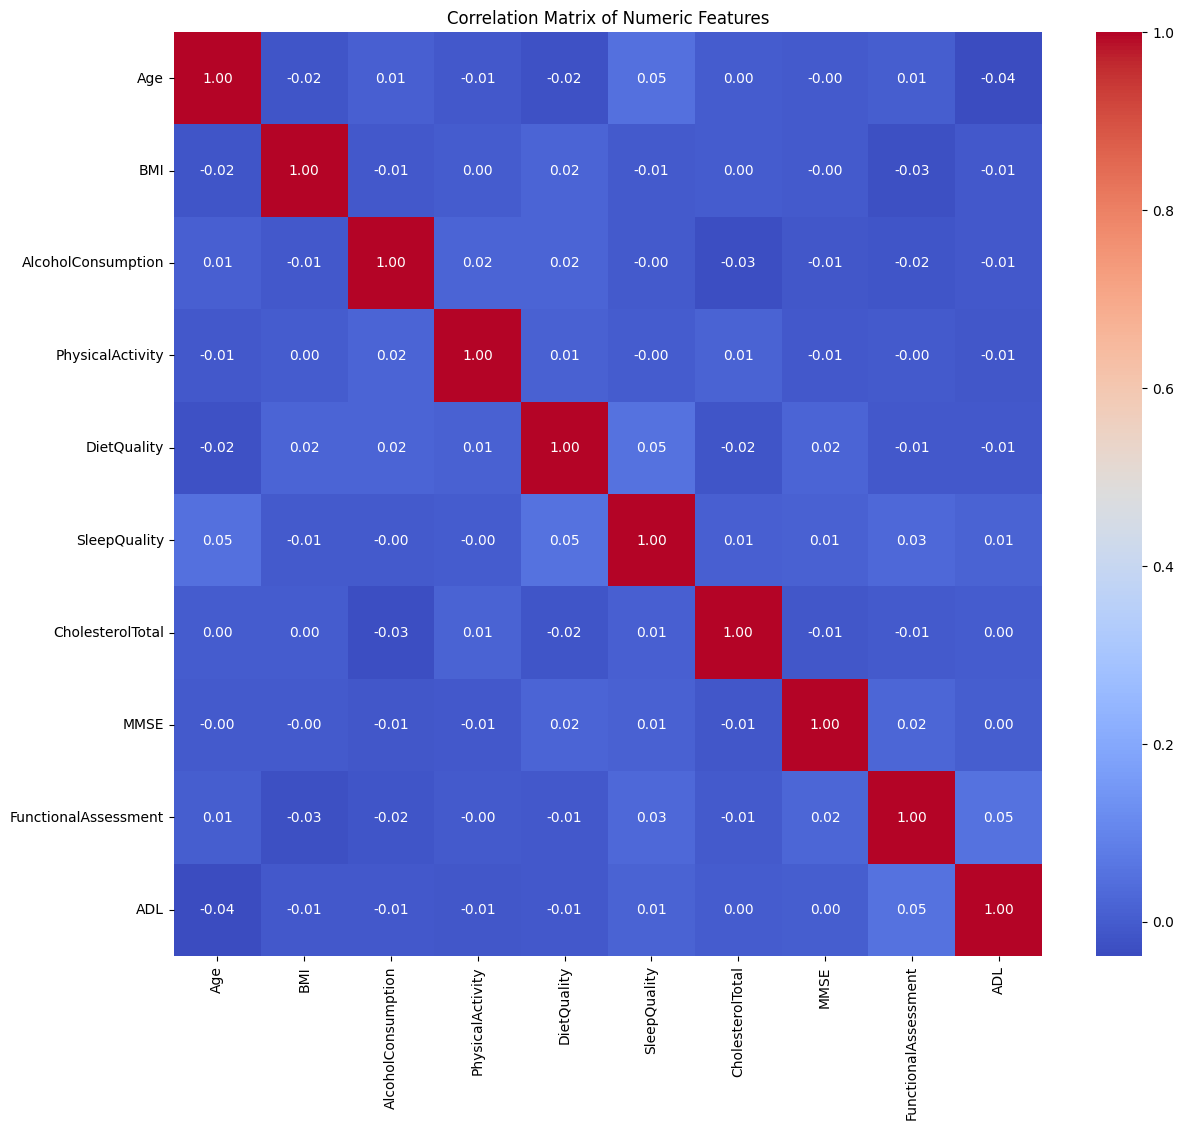

In [114]:
# Creating a correlation matrix for numerical values only
# Compute correlation
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

## Visualizing Feature Distributions

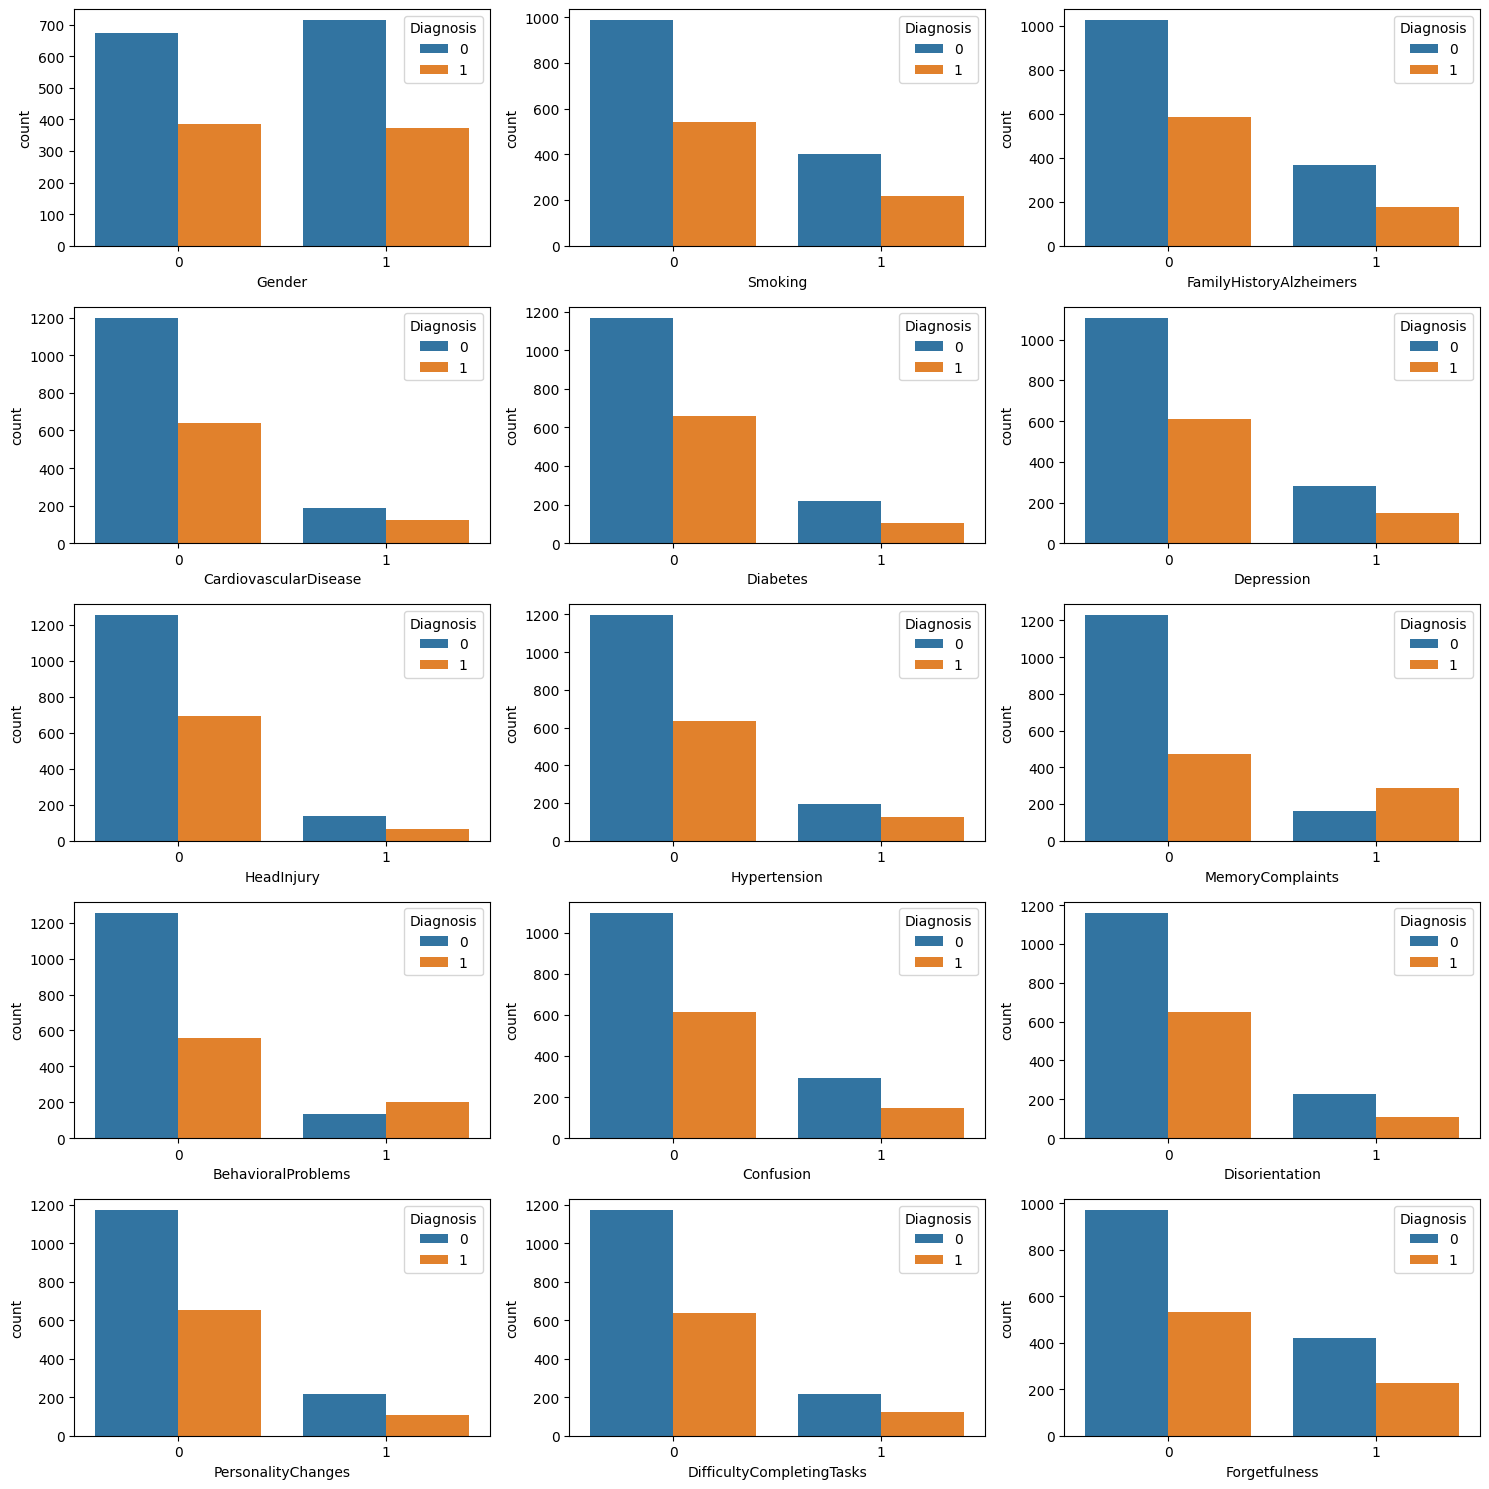

In [99]:
# Visualizing how each binary feature relates to diagnosis
fig, axes = plt.subplots(5, 3, figsize=(15,15))
for i, col in enumerate(binary_cols):
    sns.countplot(x=col, hue='Diagnosis', data=df, ax=axes[i//3, i%3])
plt.tight_layout()
plt.show()

Within these visualizations we can see interesting patterns between the fact that gender has a fairly even distribution between male and female diagnosis. On the other hand MemoryComplaints has more people with a positive diagnosis in proportion to not. BehavioralProblems also has a higher proportion of people with a positive daignosis in the positive category.

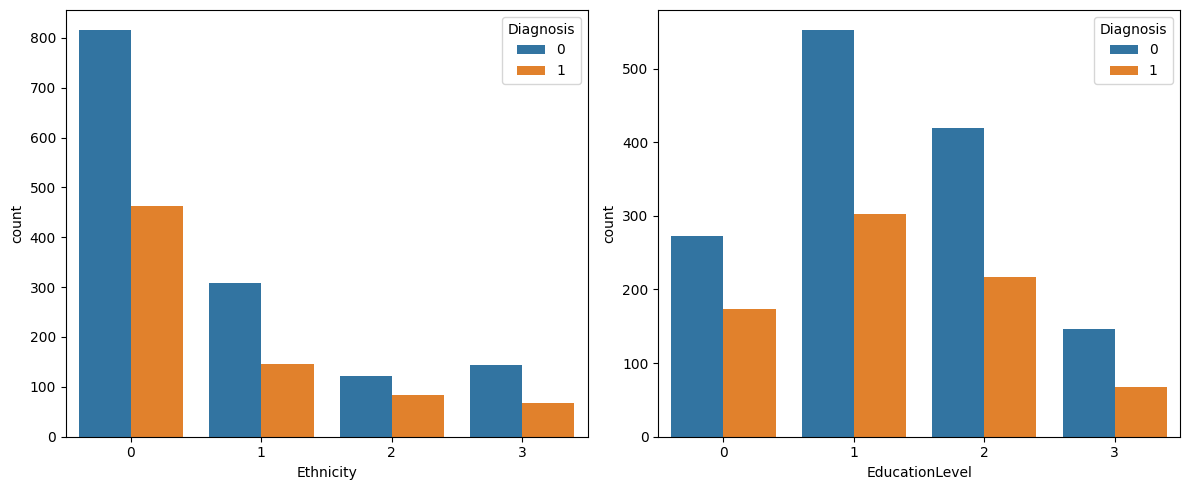

In [100]:
# Visualizing categorical values compared to diagnosis
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='Diagnosis', data=df, ax=axes[i])
plt.tight_layout()
plt.show()

Within these distributions we can see that the ethnicity categories that are not white have a much smaller count in total which might be caused by sampling error or some bias within the dataset.

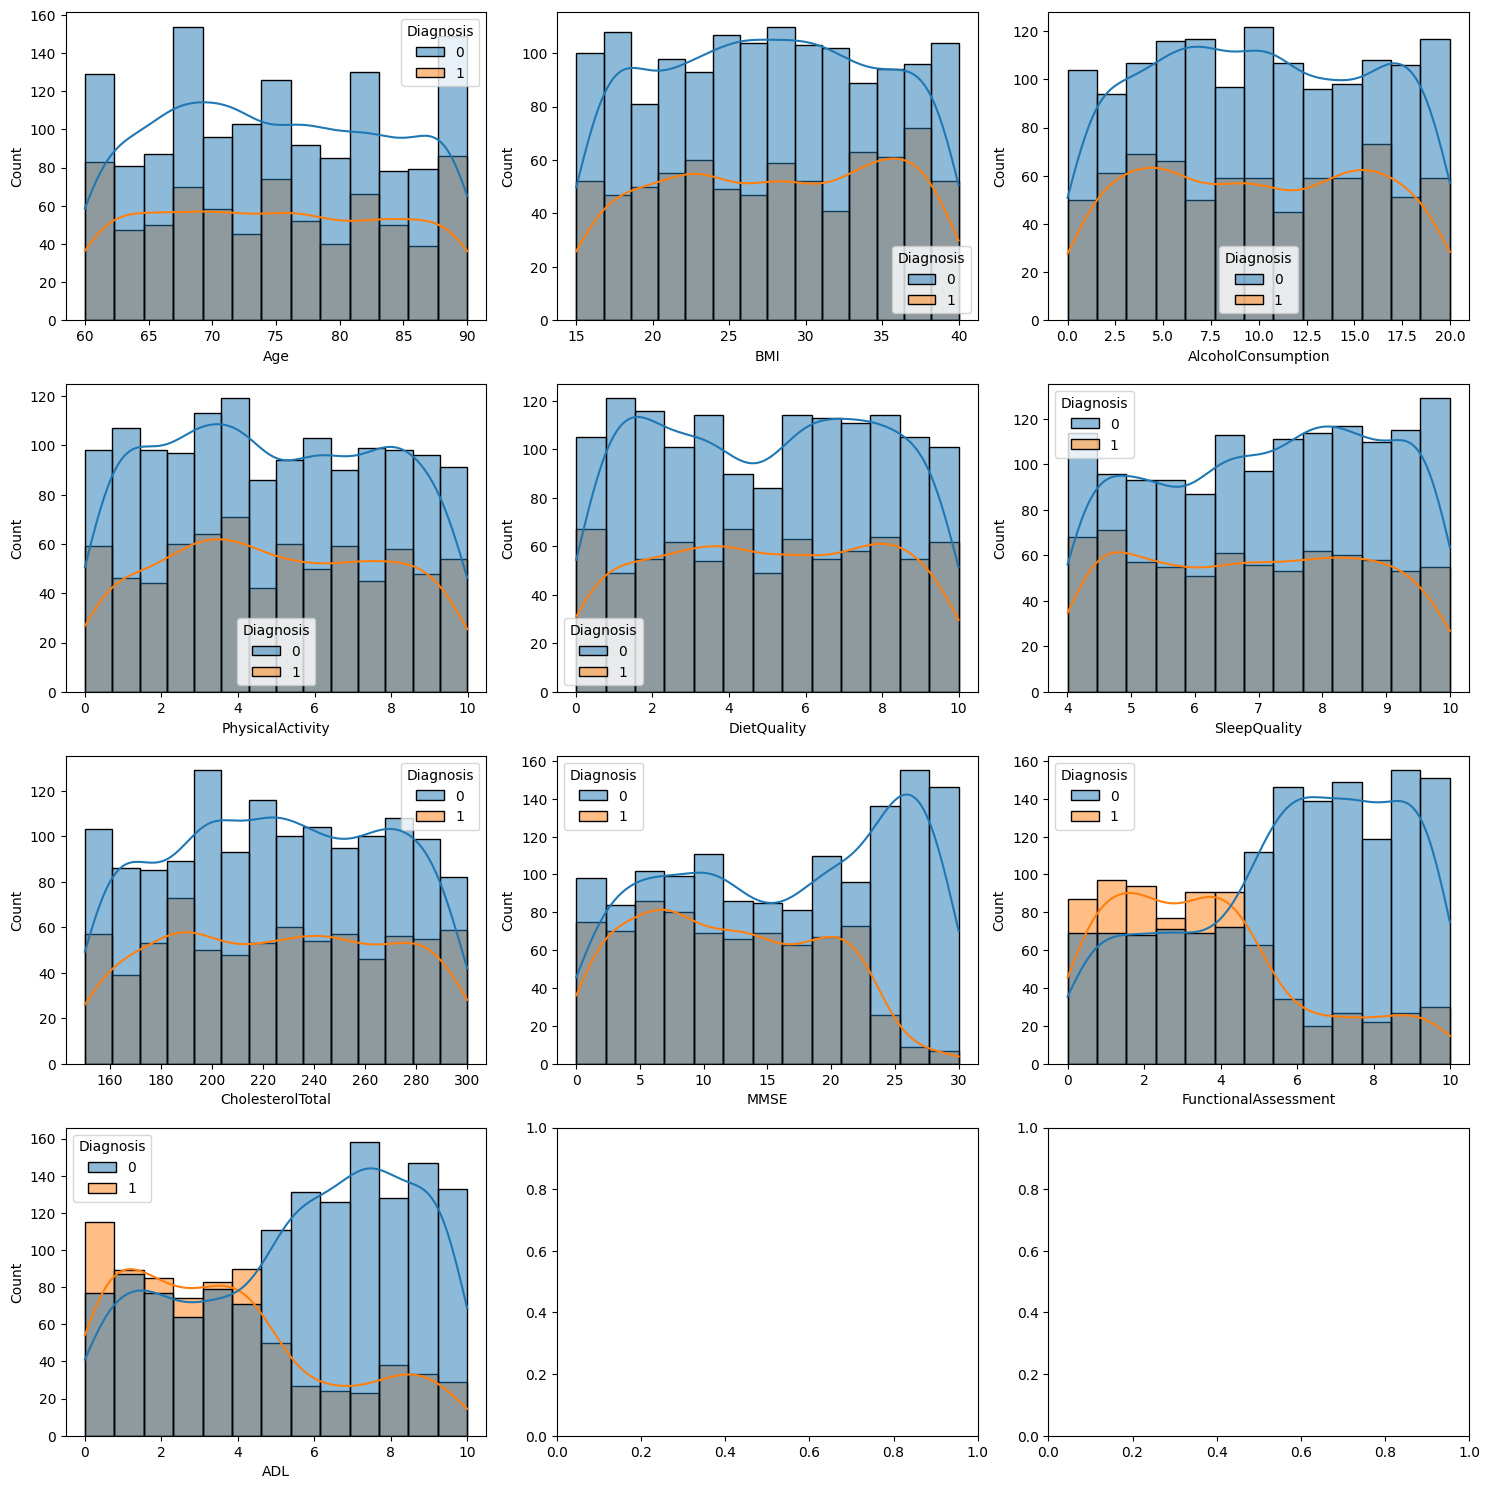

In [101]:
# Visualizing the Numerical categories
fig, axes = plt.subplots(len(numerical_cols)//3+1, 3, figsize=(15, 15))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue="Diagnosis", kde=True, ax=axes[i])
plt.tight_layout()
plt.show()

# Train Test Split

In [102]:
# Computing a 80/20 Train/Test Split
# Random State = 42
X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# PreProcessing Pipelines

In [103]:
# normalizing the binary and categorical columns using Standard Scaler and OneHotEncoder functions
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('bin', 'passthrough', binary_cols)
    ]
)

# Training Models

In [104]:
# Storing results here in order to compare afterwards
results = []

In [105]:
# Detailing each model type and parameters needed
models = [
    ("Naive Bayes", GaussianNB(), {}),
    ("KNN", KNeighborsClassifier(), {'n_neighbors':[3,5,7], 'weights':['uniform','distance']}),
    ("Decision Tree", DecisionTreeClassifier(random_state=42), {'max_depth':[None,5,10], 'min_samples_split':[2,5]}),
    ("Logistic Regression", LogisticRegression(max_iter=1000), {'C':[0.01,0.1,1,10]}),
    ("Random Forest", RandomForestClassifier(random_state=42), {'n_estimators':[50,100], 'max_depth':[None,5,10]}),
    ("SVM", SVC(), {'C':[0.1,1,10], 'kernel':['linear','rbf']}),
    ("Gradient Boosting", GradientBoostingClassifier(random_state=42), {'n_estimators':[50,100], 'learning_rate':[0.01,0.1]})
]



===== Training Naive Bayes =====


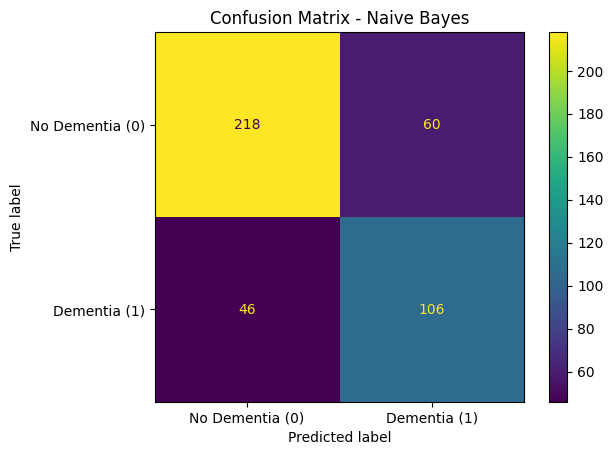

Best params: {}
Efficiency Score 0.02
Cross-Val Accuracy: 0.79
Cross-Val Recall: 0.69
Test Accuracy: 0.75
Test Recall: 0.7
Training time (s): 3.46
Prediction time (s): 0.01

===== Training KNN =====


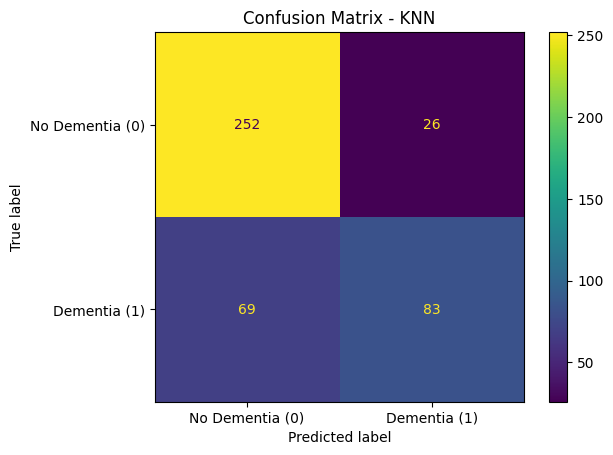

Best params: {'classifier__n_neighbors': 7, 'classifier__weights': 'uniform'}
Efficiency Score 0.02
Cross-Val Accuracy: 0.77
Cross-Val Recall: 0.54
Test Accuracy: 0.78
Test Recall: 0.55
Training time (s): 1.06
Prediction time (s): 0.01

===== Training Decision Tree =====


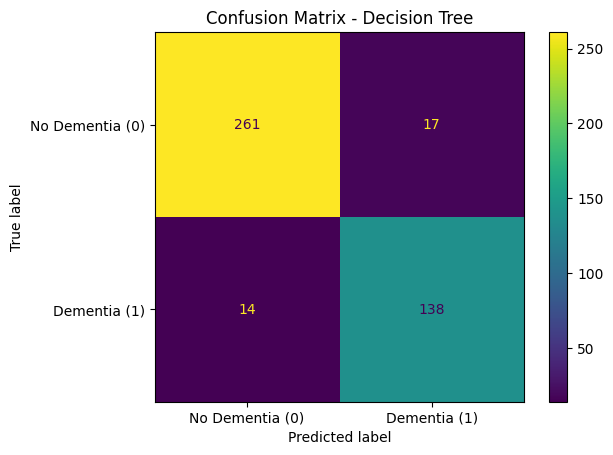

Best params: {'classifier__max_depth': 5, 'classifier__min_samples_split': 2}
Efficiency Score 0.03
Cross-Val Accuracy: 0.94
Cross-Val Recall: 0.9
Test Accuracy: 0.93
Test Recall: 0.91
Training time (s): 1.26
Prediction time (s): 0.01

===== Training Logistic Regression =====


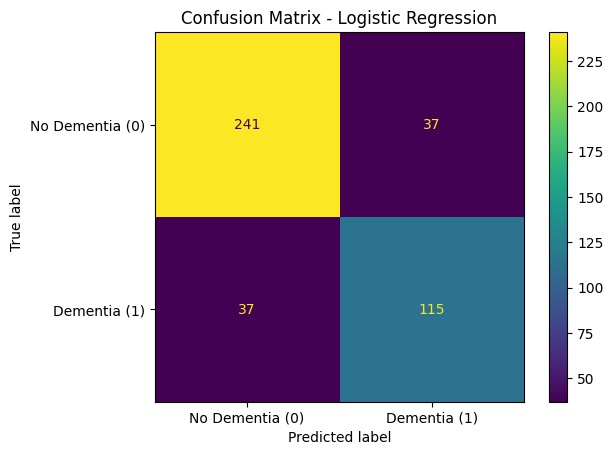

Best params: {'classifier__C': 1}
Efficiency Score 0.03
Cross-Val Accuracy: 0.84
Cross-Val Recall: 0.73
Test Accuracy: 0.83
Test Recall: 0.76
Training time (s): 0.94
Prediction time (s): 0.02

===== Training Random Forest =====


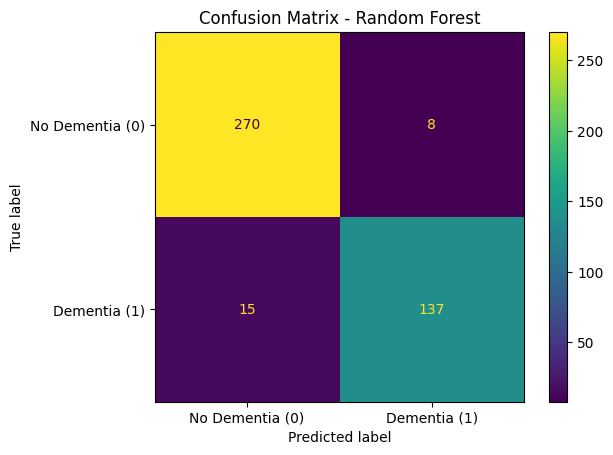

Best params: {'classifier__max_depth': None, 'classifier__n_estimators': 100}
Efficiency Score 0.03
Cross-Val Accuracy: 0.94
Cross-Val Recall: 0.86
Test Accuracy: 0.95
Test Recall: 0.9
Training time (s): 9.07
Prediction time (s): 0.02

===== Training SVM =====


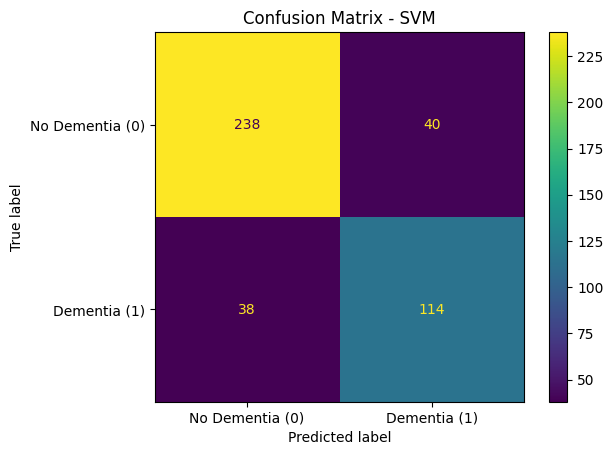

Best params: {'classifier__C': 1, 'classifier__kernel': 'linear'}
Efficiency Score 0.03
Cross-Val Accuracy: 0.84
Cross-Val Recall: 0.73
Test Accuracy: 0.82
Test Recall: 0.75
Training time (s): 2.67
Prediction time (s): 0.01

===== Training Gradient Boosting =====


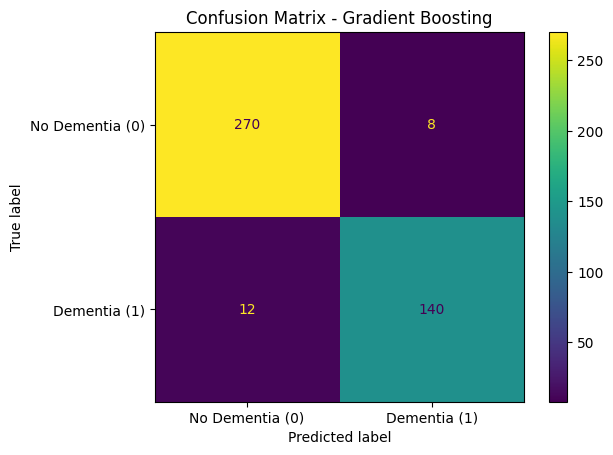

Best params: {'classifier__learning_rate': 0.1, 'classifier__n_estimators': 50}
Efficiency Score 0.03
Cross-Val Accuracy: 0.95
Cross-Val Recall: 0.92
Test Accuracy: 0.95
Test Recall: 0.92
Training time (s): 7.98
Prediction time (s): 0.01


In [106]:
for i, (name, model, param_grid) in enumerate(models):
    print(f"\n===== Training {name} =====")

    # Wrap model in a pipeline with preprocessor
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Update param_grid keys to include classifier prefix
    param_grid_prefixed = {f"classifier__{k}": v for k, v in param_grid.items()}

    grid = GridSearchCV(pipe, param_grid=param_grid_prefixed, cv=5, scoring='accuracy', n_jobs=-1)

    # Train and evaluate
    start_train = time.time()
    grid.fit(X_train, y_train)
    end_train = time.time()

    best_model = grid.best_estimator_
    start_pred = time.time()
    y_pred = best_model.predict(X_test)
    end_pred = time.time()

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Dementia (0)", "Dementia (1)"])
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    cv_recall = cross_val_score(best_model, X_train, y_train, cv=5, scoring='recall').mean()
    cv_accuracy = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy').mean()

    efficiency_score = (cv_accuracy ** 2) / X_train.shape[1]

    print("Best params:", grid.best_params_)
    print("Efficiency Score", round(efficiency_score, 2))
    print("Cross-Val Accuracy:", round(cv_accuracy, 2))
    print("Cross-Val Recall:", round(cv_recall, 2))
    print("Test Accuracy:", round(acc, 2))
    print("Test Recall:", round(rec, 2))
    print("Training time (s):", round(end_train - start_train, 2))
    print("Prediction time (s):", round(end_pred - start_pred, 2))

    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Efficiency Score": round(efficiency_score, 2),
        "CV Accuracy": round(cv_accuracy, 2),
        "CV Recall": round(cv_recall, 2),
        "Test Accuracy": round(acc, 2),
        "Test Recall": round(rec, 2),
        "Train Time (s)": round(end_train - start_train, 2),
        "Pred Time (s)": round(end_pred - start_pred, 2)
    })

In [107]:
# Print out the results in a table sorted by CV accuracy
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="CV Accuracy", ascending=False)
results_df

,Model,Best Params,Efficiency Score,CV Accuracy,CV Recall,Test Accuracy,Test Recall,Train Time (s),Pred Time (s)
6,Gradient Boosting,"{'classifier__learning_rate': 0.1, 'classifier...",0.03,0.95,0.92,0.95,0.92,7.98,0.01
4,Random Forest,"{'classifier__max_depth': None, 'classifier__n...",0.03,0.94,0.86,0.95,0.90,9.07,0.02
2,Decision Tree,"{'classifier__max_depth': 5, 'classifier__min_...",0.03,0.94,0.90,0.93,0.91,1.26,0.01
3,Logistic Regression,{'classifier__C': 1},0.03,0.84,0.73,0.83,0.76,0.94,0.02
5,SVM,"{'classifier__C': 1, 'classifier__kernel': 'li...",0.03,0.84,0.73,0.82,0.75,2.67,0.01
0,Naive Bayes,{},0.02,0.79,0.69,0.75,0.70,3.46,0.01
1,KNN,"{'classifier__n_neighbors': 7, 'classifier__we...",0.02,0.77,0.54,0.78,0.55,1.06,0.01


# Going a Step Further

# Conclusion and Discussion